# Signals Slicing

In [ ]:
pip install pandas matplotlib numpy

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === CONFIGURATION ===
source_dir = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset/Dataset 1 - CTU CHB/interpolated-denoised signals (csv, Hermite)'  # Full path to your signal .csv files
label_file = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset/Dataset 1 - CTU CHB/ctu_df.csv'  # Full path to final.csv (ID to target mapping)
output_base = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset/Dataset 1 - CTU CHB/CNN'  # Output folder for image segments
segment_duration = 1200  # 1200 seconds (20 minutes)
max_segments = 10        # Max segments per file

In [ ]:
# === CREATE CLASS FOLDERS ===
os.makedirs(output_base, exist_ok=True)
label_df = pd.read_csv(label_file)
label_df['ID'] = label_df['ID'].astype(str)
unique_labels = label_df['target'].unique()

for label in unique_labels:
    class_folder = os.path.join(output_base, f'class_{label}')
    os.makedirs(class_folder, exist_ok=True)

In [ ]:
# === BUILD LABEL DICTIONARY ===
label_dict = {row['ID']: row['target'] for _, row in label_df.iterrows()}

# === PROCESS EACH FILE ===
for filename in os.listdir(source_dir):
    if filename.endswith('.csv'):
        patient_id = filename.split('.')[0]

        label = label_dict.get(patient_id)
        if label is None:
            print(f"Skipping {filename} (label not found)")
            continue

        file_path = os.path.join(source_dir, filename)
        df = pd.read_csv(file_path)

        # Choose FHR_denoised if available, else fallback to FHR
        fhr_column = 'FHR_denoised' if 'FHR_denoised' in df.columns else 'FHR'
        if fhr_column not in df.columns or 'seconds' not in df.columns:
            print(f"Skipping {filename} (missing 'seconds' or '{fhr_column}')")
            continue

        max_time = df['seconds'].max()
        num_segments = min(max_segments, int(max_time // segment_duration))

        for i in range(num_segments):
            start_time = i * segment_duration
            end_time = start_time + segment_duration
            segment = df[(df['seconds'] >= start_time) & (df['seconds'] < end_time)]

            if len(segment) < 10:
                continue  # Skip if too few data points

            plt.figure(figsize=(10, 4))
            plt.plot(segment['seconds'], segment[fhr_column], color='blue', linewidth=1)
            plt.xlabel('Seconds')
            plt.ylabel('FHR')
            plt.title(f'{filename} - Segment {i+1}')
            plt.grid(True)

            save_filename = f'{patient_id}_segment_{i+1}.png'
            save_path = os.path.join(output_base, f'class_{label}', save_filename)
            plt.savefig(save_path)
            plt.close()

print("✅ Done! All signal segments have been processed and saved as images.")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FHR_CNN(nn.Module):
    def __init__(self, input_channels=1, num_classes=2):  # adjust `num_classes` accordingly
        super(FHR_CNN, self).__init__()
        
        self.conv_block1 = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256 * 150, 128)  # Update 150 based on final time steps after pooling
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=1)


# Signals Slicing 2

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# === CONFIGURATION ===
source_dir = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset/Dataset 1 - CTU CHB/interpolated-denoised signals (csv, Hermite)'
label_file = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset/Dataset 1 - CTU CHB/ctu_df.csv'
output_base = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset/Dataset 1 - CTU CHB/CNN'
segment_duration = 1200
max_segments = 10

In [3]:
# === CREATE CLASS FOLDERS ===
os.makedirs(output_base, exist_ok=True)
label_df = pd.read_csv(label_file)
label_df['ID'] = label_df['ID'].astype(str)
unique_labels = label_df['target'].unique()

for label in unique_labels:
    class_folder = os.path.join(output_base, f'class_{label}')
    os.makedirs(class_folder, exist_ok=True)

# === BUILD LABEL DICTIONARY ===
label_dict = {row['ID']: row['target'] for _, row in label_df.iterrows()}

In [4]:
# === PROCESS EACH FILE ===
for filename in os.listdir(source_dir):
    if filename.endswith('.csv'):
        patient_id = filename.split('.')[0]

        label = label_dict.get(patient_id)
        if label is None:
            print(f"Skipping {filename} (label not found)")
            continue

        file_path = os.path.join(source_dir, filename)
        df = pd.read_csv(file_path)

        fhr_column = 'FHR_denoised' if 'FHR_denoised' in df.columns else 'FHR'
        if fhr_column not in df.columns or 'seconds' not in df.columns:
            print(f"Skipping {filename} (missing 'seconds' or '{fhr_column}')")
            continue

        max_time = df['seconds'].max()
        num_segments = min(max_segments, int(max_time // segment_duration))

        for i in range(num_segments):
            start_time = i * segment_duration
            end_time = start_time + segment_duration
            segment = df[(df['seconds'] >= start_time) & (df['seconds'] < end_time)]

            if len(segment) < 10:
                continue

            # === PLOT without grid/titles/axes ===
            fig, ax = plt.subplots(figsize=(10, 4))
            ax.plot(segment['seconds'], segment[fhr_column], color='blue', linewidth=1)
            ax.axis('off')  # removes all axes, ticks, and labels
            plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # fill the whole canvas
            fig.patch.set_facecolor('white')  # white background

            # === SAVE IMAGE ===
            save_filename = f'{patient_id}_segment_{i+1}.png'
            save_path = os.path.join(output_base, f'class_{label}', save_filename)
            plt.savefig(save_path, dpi=100)
            plt.close()

print("✅ Done! All signal segments saved as clean waveform images.")

✅ Done! All signal segments saved as clean waveform images.


# 2D-CNN Model (Without Oversampling/Undersampling) [1]

In [ ]:
pip install scikit-learn

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# === Hyperparameters / Configurations ===
data_dir = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset/Dataset 1 - CTU CHB/2D-CNN'  # Directory with class_0 and class_1 folders
IMG_SIZE = (120, 120)
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 2
TRAIN_RATIO = 0.8 # 80% training 20% testing
EARLY_STOPPING_PATIENCE = 5 

In [3]:
# === CNN Architecture ===
class FHR_CNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(FHR_CNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Flatten(),
            nn.Linear(128 * (IMG_SIZE[0] // 8) * (IMG_SIZE[1] // 8), 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)


In [5]:
# === Transformations ===
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor()
])

# === Load Full Dataset ===
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
all_indices = list(range(len(full_dataset)))
all_labels = [full_dataset[i][1] for i in all_indices]




In [7]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
# === Stratified Train-Test Split ===
train_idx, test_idx = train_test_split(all_indices, stratify=all_labels, train_size=TRAIN_RATIO, random_state=42)
train_dataset = Subset(full_dataset, train_idx)
test_dataset = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
# === Initialize Model ===
device = torch.device('cpu')
model = FHR_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# === Training Loop with Early Stopping ===
best_val_loss = float('inf')
patience_counter = 0
epoch_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    epoch_losses.append(avg_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(test_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {avg_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered! 🚦")
            break


Epoch 1/10, Train Loss: 0.5072, Val Loss: 0.4852
Epoch 2/10, Train Loss: 0.4920, Val Loss: 0.4903
Epoch 3/10, Train Loss: 0.4915, Val Loss: 0.4889
Epoch 4/10, Train Loss: 0.4949, Val Loss: 0.4938
Epoch 5/10, Train Loss: 0.4894, Val Loss: 0.4888
Epoch 6/10, Train Loss: 0.4883, Val Loss: 0.4865
Early stopping triggered! 🚦


In [9]:
# === Evaluation ===
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

print("\n=== Classification Report (on test set) ===")
print(classification_report(all_targets, all_preds, digits=4))



=== Classification Report (on test set) ===
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       210
           1     0.8098    1.0000    0.8949       894

    accuracy                         0.8098      1104
   macro avg     0.4049    0.5000    0.4474      1104
weighted avg     0.6557    0.8098    0.7247      1104



c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

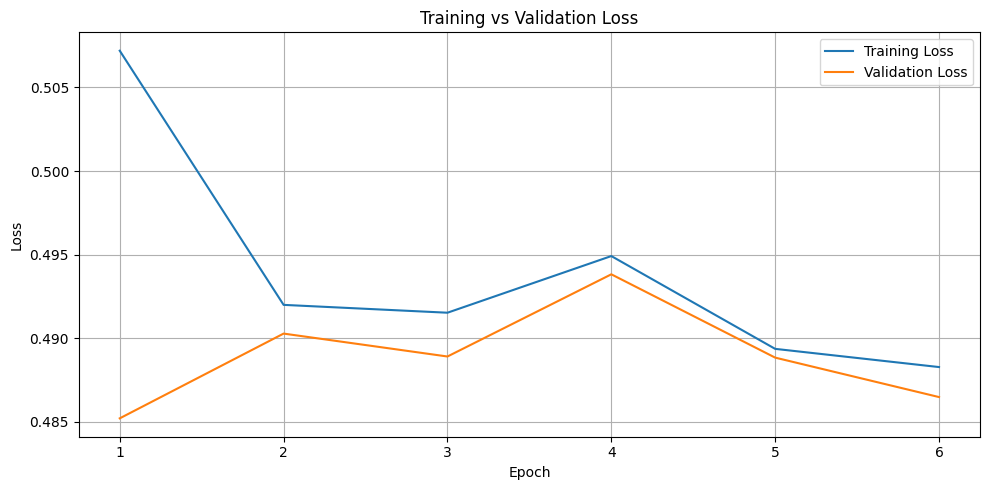

In [10]:
# === Plot Training vs Validation Loss ===
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(epoch_losses)+1), epoch_losses, label='Training Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 2D-CNN Model (Without Oversampling/Undersampling) [2]

Better Validation-Test Loss Curve

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

In [7]:
# === CONFIGURATION ===
data_dir = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset/Dataset 1 - CTU CHB/CNN'  # Directory with class_0 and class_1 folders
IMG_SIZE = (120, 120)
BATCH_SIZE = 32
EPOCHS = 15
NUM_CLASSES = 2
TRAIN_RATIO = 0.8
EARLY_STOPPING_PATIENCE = 5

In [8]:
# === CNN Architecture ===
class FHR_CNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(FHR_CNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128 * (IMG_SIZE[0] // 8) * (IMG_SIZE[1] // 8), 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)


In [9]:
# === Transformations ===
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor()
])

# === Load Full Dataset ===
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
all_indices = list(range(len(full_dataset)))
all_labels = [full_dataset[i][1] for i in all_indices]

# === Stratified Train-Test Split ===
train_idx, test_idx = train_test_split(all_indices, stratify=all_labels, train_size=TRAIN_RATIO, random_state=42)
train_dataset = Subset(full_dataset, train_idx)
test_dataset = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# === Compute Weighted Loss ===
train_labels = [full_dataset[i][1] for i in train_idx]
label_counts = Counter(train_labels)
total = sum(label_counts.values())
class_weights = [total / label_counts[i] for i in range(NUM_CLASSES)]
class_weights_tensor = torch.FloatTensor(class_weights)


In [10]:
# === Initialize Model ===
device = torch.device('cpu')
model = FHR_CNN().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)

# === Training Loop with Early Stopping ===
best_val_loss = float('inf')
patience_counter = 0
epoch_losses = []
val_losses = []

EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    epoch_losses.append(avg_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(test_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {avg_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered! 🚦")
            break


Epoch 1/15, Train Loss: 0.6944, Val Loss: 0.6930
Epoch 2/15, Train Loss: 0.6936, Val Loss: 0.6928
Epoch 3/15, Train Loss: 0.6934, Val Loss: 0.6932
Epoch 4/15, Train Loss: 0.6929, Val Loss: 0.6928
Epoch 5/15, Train Loss: 0.6929, Val Loss: 0.6927
Epoch 6/15, Train Loss: 0.6928, Val Loss: 0.6927
Epoch 7/15, Train Loss: 0.6929, Val Loss: 0.6927
Epoch 8/15, Train Loss: 0.6925, Val Loss: 0.6927
Epoch 9/15, Train Loss: 0.6928, Val Loss: 0.6927
Epoch 10/15, Train Loss: 0.6926, Val Loss: 0.6927
Epoch 11/15, Train Loss: 0.6927, Val Loss: 0.6927
Epoch 12/15, Train Loss: 0.6924, Val Loss: 0.6927
Epoch 13/15, Train Loss: 0.6928, Val Loss: 0.6927
Early stopping triggered! 🚦


In [11]:
# === Evaluation ===
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

print("\n=== Classification Report (on test set) ===")
print(classification_report(all_targets, all_preds, digits=4))



=== Classification Report (on test set) ===
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       210
           1     0.8098    1.0000    0.8949       894

    accuracy                         0.8098      1104
   macro avg     0.4049    0.5000    0.4474      1104
weighted avg     0.6557    0.8098    0.7247      1104



c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

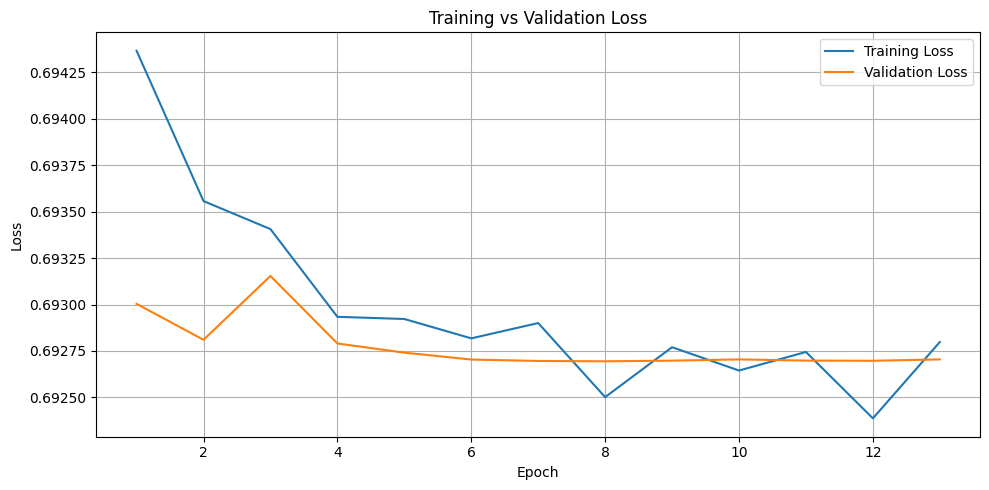

In [12]:
# === Plot Training vs Validation Loss ===
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(epoch_losses)+1), epoch_losses, label='Training Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 2D-CNN Model (Without Oversampling/Undersampling) [3]

In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

In [ ]:
# === CONFIGURATION ===
data_dir = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset/Dataset 1 - CTU CHB/CNN'  # Directory with class_0 and class_1 folders
IMG_SIZE = (120, 120)
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 2
TRAIN_RATIO = 0.8
EARLY_STOPPING_PATIENCE = 5
MAX_CLASS_1_SAMPLES = 1050  # downsampling target for class 1

In [36]:
# === CNN Architecture ===
class FHR_CNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(FHR_CNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128 * (IMG_SIZE[0] // 8) * (IMG_SIZE[1] // 8), 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [37]:
# === Transformations ===
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor()
])

# === Load Full Dataset ===
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
all_indices = list(range(len(full_dataset)))
all_labels = [full_dataset[i][1] for i in all_indices]


In [38]:
# === Downsample Class 1 ===
class_0_indices = [idx for idx in all_indices if full_dataset[idx][1] == 0]
class_1_indices = [idx for idx in all_indices if full_dataset[idx][1] == 1]
np.random.seed(42)
downsampled_class_1_indices = np.random.choice(class_1_indices, size=min(MAX_CLASS_1_SAMPLES, len(class_1_indices)), replace=False)
balanced_indices = class_0_indices + list(downsampled_class_1_indices)
np.random.shuffle(balanced_indices)
balanced_labels = [full_dataset[i][1] for i in balanced_indices]

# === Stratified Train-Test Split ===
train_idx, test_idx = train_test_split(balanced_indices, stratify=balanced_labels, train_size=TRAIN_RATIO, random_state=42)
train_dataset = Subset(full_dataset, train_idx)
test_dataset = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# === Compute Weighted Loss ===
train_labels = [full_dataset[i][1] for i in train_idx]
label_counts = Counter(train_labels)
total = sum(label_counts.values())
class_weights = [total / label_counts[i] for i in range(NUM_CLASSES)]
class_weights_tensor = torch.FloatTensor(class_weights)


In [39]:
# === Initialize Model ===
device = torch.device('cpu')
model = FHR_CNN().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)

# === Training Loop with Early Stopping ===
best_val_loss = float('inf')
patience_counter = 0
epoch_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    epoch_losses.append(avg_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(test_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {avg_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered! 🚦")
            break


Epoch 1/20, Train Loss: 0.7212, Val Loss: 0.6932
Epoch 2/20, Train Loss: 0.6932, Val Loss: 0.6931
Epoch 3/20, Train Loss: 0.6932, Val Loss: 0.6931
Epoch 4/20, Train Loss: 0.6932, Val Loss: 0.6931
Epoch 5/20, Train Loss: 0.6933, Val Loss: 0.6931
Epoch 6/20, Train Loss: 0.6932, Val Loss: 0.6931
Epoch 7/20, Train Loss: 0.6932, Val Loss: 0.6931
Epoch 8/20, Train Loss: 0.6932, Val Loss: 0.6931
Epoch 9/20, Train Loss: 0.6932, Val Loss: 0.6931
Epoch 10/20, Train Loss: 0.6933, Val Loss: 0.6931
Epoch 11/20, Train Loss: 0.6932, Val Loss: 0.6932
Epoch 12/20, Train Loss: 0.6932, Val Loss: 0.6931
Epoch 13/20, Train Loss: 0.6933, Val Loss: 0.6932
Early stopping triggered! 🚦


In [40]:
# === Evaluation ===
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

print("\n=== Classification Report (on test set) ===")
print(classification_report(all_targets, all_preds, digits=4))


=== Classification Report (on test set) ===
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       210
           1     0.5000    1.0000    0.6667       210

    accuracy                         0.5000       420
   macro avg     0.2500    0.5000    0.3333       420
weighted avg     0.2500    0.5000    0.3333       420



c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

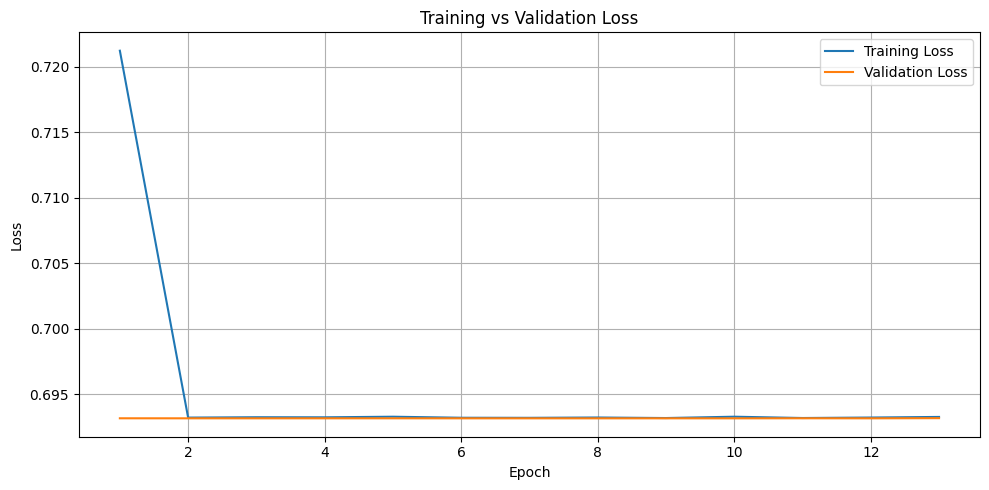

In [41]:
# === Plot Training vs Validation Loss ===
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(epoch_losses)+1), epoch_losses, label='Training Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 2D-CNN Model , no-grid signals only , Meso Net CNN [3]

In [2]:
# Importing all the modules
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, SeparableConv2D, BatchNormalization, Activation, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [3]:
# === CONFIGURATION ===
data_dir = 'D:/MSc. Asutosh/Final Year Project (Fetal Death Diagnosis Research)/Final Dataset/Dataset 1 - CTU CHB/CNN'
IMG_HEIGHT, IMG_WIDTH = 112, 336
BATCH_SIZE = 32
EPOCHS = 20


In [4]:
# === MesoNet Model ===
def build_meso_model(input_shape=(112, 336, 3), dropout=0.3, filters=16):
    input_layer = Input(shape=input_shape)

    x = SeparableConv2D(filters, (3, 3), padding='same')(input_layer)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2), padding='same')(x)

    x = SeparableConv2D(filters, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2), padding='same')(x)

    x = SeparableConv2D(32, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2), padding='same')(x)

    x = SeparableConv2D(32, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(4, 4), padding='same')(x)

    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout)(x)
    x = Dense(16, activation='relu')(x)
    x = Dropout(dropout)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=input_layer, outputs=output)
    return model

In [5]:
# === IMAGE LOADER ===
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 4416 images belonging to 2 classes.
Found 1104 images belonging to 2 classes.


In [6]:
# === BUILD & COMPILE ===
model = build_meso_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# === TRAIN ===
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen
)

Epoch 1/20
138/138 [==============================] - 74s 519ms/step - loss: 0.5773 - accuracy: 0.7665 - val_loss: 0.6102 - val_accuracy: 0.8098
Epoch 2/20
138/138 [==============================] - 55s 399ms/step - loss: 0.5259 - accuracy: 0.8057 - val_loss: 0.5399 - val_accuracy: 0.8098
Epoch 3/20
138/138 [==============================] - 56s 406ms/step - loss: 0.5153 - accuracy: 0.8066 - val_loss: 0.5219 - val_accuracy: 0.8098
Epoch 4/20
138/138 [==============================] - 55s 401ms/step - loss: 0.5088 - accuracy: 0.8082 - val_loss: 0.4962 - val_accuracy: 0.8098
Epoch 5/20
138/138 [==============================] - 56s 406ms/step - loss: 0.5030 - accuracy: 0.8098 - val_loss: 0.4930 - val_accuracy: 0.8098
Epoch 6/20
138/138 [==============================] - 56s 402ms/step - loss: 0.4993 - accuracy: 0.8098 - val_loss: 0.5020 - val_accuracy: 0.8098
Epoch 7/20
138/138 [==============================] - 55s 400ms/step - loss: 0.5053 - accuracy: 0.8096 - val_loss: 0.4954 - val_ac

In [7]:
# === EVALUATION ===
# Predict on validation set
val_gen.reset()
y_true = val_gen.classes
y_pred = model.predict(val_gen)
y_pred_labels = (y_pred > 0.5).astype(int).flatten()

# Report
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred_labels, digits=4))

35/35 [==============================] - 7s 197ms/step

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       210
           1     0.8098    1.0000    0.8949       894

    accuracy                         0.8098      1104
   macro avg     0.4049    0.5000    0.4474      1104
weighted avg     0.6557    0.8098    0.7247      1104



c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

In [8]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[  0 210]
 [  0 894]]


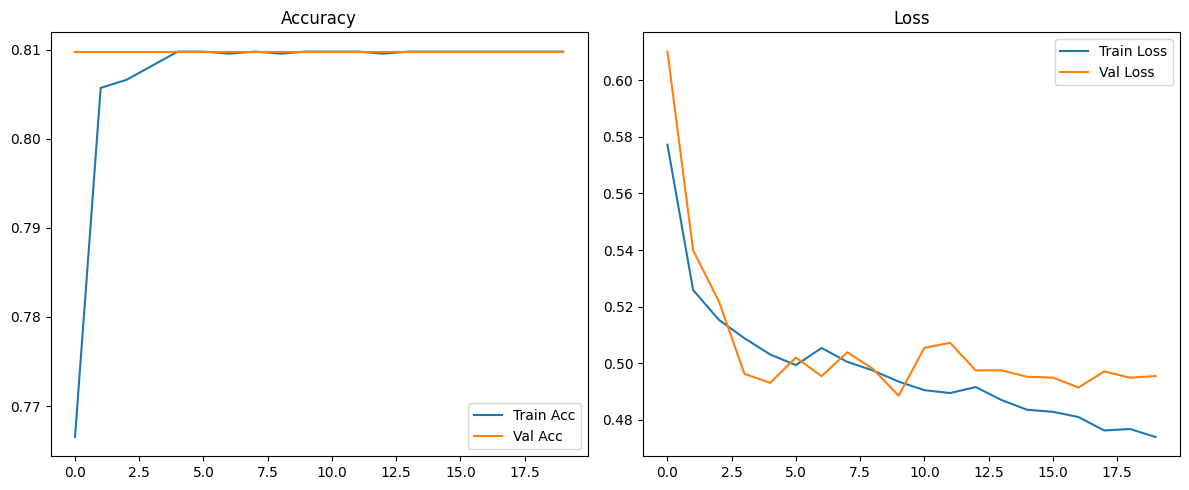

In [9]:
# === Plot Loss/Accuracy ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
unique, counts = np.unique(train_labels, return_counts=True)
print("Training set distribution:", dict(zip(unique, counts)))


NameError: name 'train_labels' is not defined